In [28]:
%pip install wordcloud
%pip install spacy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import seaborn as sns
from wordcloud import WordCloud
import spacy
from sklearn.decomposition import PCA

# Expanded dataset with 100 reviews
reviews = [
    "The camera quality is excellent and battery life is good.",
    "Battery drains too quickly, not happy with battery life.",
    "Love the sleek design and display quality.",
    "The speaker volume could be better but overall good product.",
    "Worth the price for the features you get.",
    "The phone gets hot during charging but performance is smooth.",
    "Amazing performance for the price point.",
    "Screen resolution is outstanding and colors are vibrant.",
    "Disappointed with the customer service experience.",
    "The fingerprint sensor is fast and accurate.",
    "Battery lasts all day with moderate usage.",
    "The user interface is intuitive and easy to navigate.",
    "Camera struggles in low light conditions.",
    "Excellent build quality and premium feel.",
    "Charging speed is impressively fast.",
    "The phone is too heavy for my liking.",
    "Bluetooth connectivity issues with my headphones.",
    "Great value for money in this price range.",
    "The selfie camera could be better.",
    "Perfect size for one-handed use.",
    "Software updates are frequent and improve performance.",
    "Microphone quality during calls is poor.",
    "Love the edge-to-edge display design.",
    "Gets laggy after a few months of use.",
    "Best phone I've ever owned, highly recommend.",
    "The vibration motor feels cheap and loud.",
    "Water resistance gives me peace of mind.",
    "The included charger is too slow.",
    "Facial recognition works perfectly even in dark.",
    "Too many pre-installed apps that can't be removed.",
    "The haptic feedback is precise and satisfying.",
    "Network reception is weaker than my previous phone.",
    "The curved screen causes accidental touches.",
    "Excellent for gaming, no lag or heating issues.",
    "The phone slipped out of my hand too easily.",
    "Night mode on the camera produces great results.",
    "Speaker quality is tinny at high volumes.",
    "The always-on display feature is very useful.",
    "Battery health degraded quickly after a year.",
    "The zoom camera is impressive for distant shots.",
    "Wish it had a headphone jack.",
    "The software is full of useful features.",
    "Screen scratches too easily, needed a protector.",
    "Perfect phone except for the bloatware.",
    "The case included in the box is low quality.",
    "Fast and reliable fingerprint scanner.",
    "The phone is too large for comfortable use.",
    "Wireless charging works flawlessly.",
    "The camera software is packed with great modes.",
    "Not worth the premium price in my opinion.",
    "The matte finish prevents fingerprints.",
    "Voice assistant is slow to respond.",
    "The display is too bright at minimum setting.",
    "Multitasking is smooth with no hiccups.",
    "The charging port became loose after few months.",
    "Love the customization options in the OS.",
    "The phone doesn't sit flat due to camera bump.",
    "Video recording quality is cinema-grade.",
    "Too much bloatware that slows down the system.",
    "The notification system is well implemented.",
    "Wish the battery lasted longer on heavy usage.",
    "The phone feels premium in hand.",
    "The screen has a yellow tint that I can't remove.",
    "Great for productivity with the multi-window feature.",
    "The auto-brightness is too aggressive.",
    "The phone survived multiple drops with no damage.",
    "The in-display fingerprint sensor is inconsistent.",
    "The ultrawide camera has significant distortion.",
    "The haptics make typing feel satisfying.",
    "The phone overheats during video calls.",
    "The macro camera produces stunning close-up shots.",
    "The power button is too flush with the frame.",
    "The dark mode implementation is excellent.",
    "The phone collects dust around the camera module.",
    "The portrait mode blurs edges perfectly.",
    "The vibration is too weak and I miss notifications.",
    "The phone supports all the latest network bands.",
    "The glass back makes it too slippery.",
    "The slow motion video quality is impressive.",
    "The phone doesn't come with screen protector applied.",
    "The app switching is fast and fluid.",
    "The earpiece volume could be louder.",
    "The phone maintains resale value well.",
    "The camera shutter lag ruins quick shots.",
    "The stereo speakers provide immersive sound.",
    "The phone is difficult to repair yourself.",
    "The AI scene detection works surprisingly well.",
    "The notification LED is sorely missed.",
    "The phone charges from 0 to 50% in 30 minutes.",
    "The curved edges cause color distortion.",
    "The gaming mode blocks notifications effectively.",
    "The phone is top-heavy with cases attached.",
    "The pro mode in camera gives full control.",
    "The screen has noticeable pwm flickering.",
    "The phone feels snappy even after 2 years.",
    "The voice recording quality is mediocre.",
    "The AR features work better than expected.",
    "The phone doesn't come with a charger anymore.",
    "The animation speeds can be adjusted which is nice.",
    "The under-display camera is noticeable in bright light.",
    "The phone supports all my banking apps perfectly.",
    "The auto-rotate is too sensitive and activates accidentally."
]

# Corresponding ratings (1-5)
ratings = [
    5, 2, 4, 3, 4, 3, 5, 5, 2, 5, 
    4, 4, 3, 5, 5, 2, 3, 5, 3, 4, 
    5, 2, 4, 3, 5, 2, 5, 3, 5, 2, 
    5, 3, 3, 5, 2, 4, 3, 5, 2, 5, 
    2, 4, 3, 4, 2, 5, 2, 5, 5, 2, 
    5, 3, 2, 5, 3, 4, 2, 5, 2, 5, 
    4, 2, 5, 3, 3, 5, 3, 5, 4, 2, 
    5, 2, 5, 3, 5, 2, 5, 3, 5, 2, 
    5, 3, 4, 2, 5, 3, 5, 2, 5, 3, 
    4, 2, 5, 3, 5, 2, 4, 3, 5, 3
]

# Ensure both lists have the same length
min_len = min(len(reviews), len(ratings))
reviews_trimmed = reviews[:min_len]
ratings_trimmed = ratings[:min_len]

# Create dataframe
df = pd.DataFrame({'review': reviews_trimmed, 'rating': ratings_trimmed})
print(f"Dataset contains {len(df)} reviews.")
print("\nRating distribution:")
print(df['rating'].value_counts())


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dataset contains 100 reviews.

Rating distribution:
rating
5    37
2    24
3    24
4    15
Name: count, dtype: int64


## Task 1: Character-Level Representation (Heatmap)


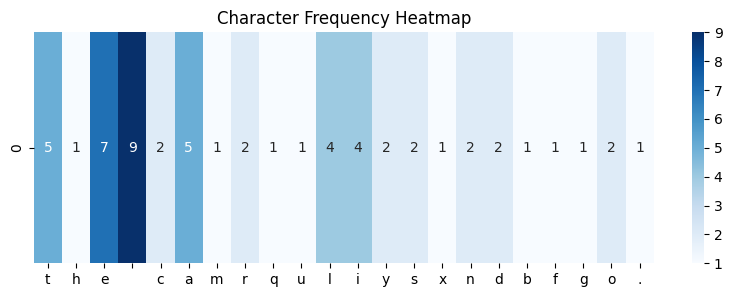

In [29]:
# Choose one review
sample_text = df['review'][0]

# Count characters (case insensitive)
char_counts = Counter(sample_text.lower())

# Create heatmap
plt.figure(figsize=(10, 3))
sns.heatmap([list(char_counts.values())], 
            xticklabels=list(char_counts.keys()),
            cmap='Blues', annot=True)
plt.title("Character Frequency Heatmap")
plt.show()

## Task 2: Word-Level Representation (Bar Chart)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rameshkunwar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


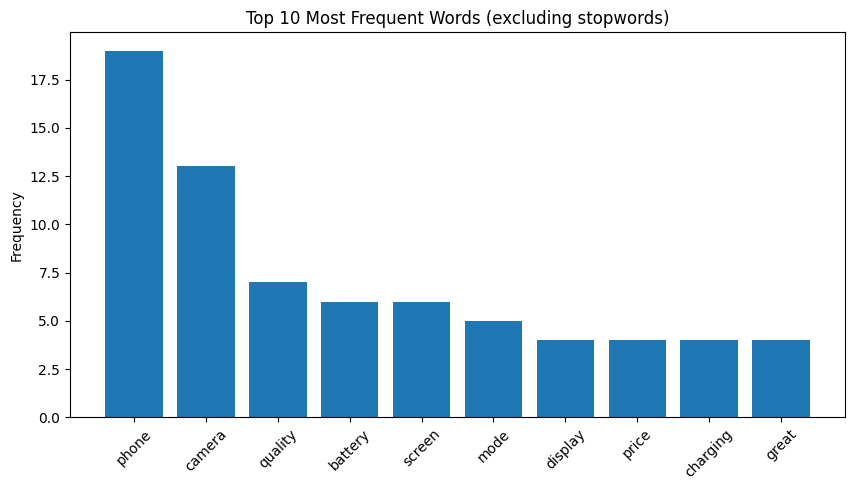

In [30]:
import sys
!{sys.executable} -m pip install nltk

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Get words from all reviews
all_words = ' '.join(df['review']).lower().split()
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in all_words if word not in stop_words and word.isalpha()]

# Count word frequencies
word_counts = Counter(filtered_words).most_common(10)

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar([word[0] for word in word_counts], [word[1] for word in word_counts])
plt.title("Top 10 Most Frequent Words (excluding stopwords)")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

## Task 3: N-Gram Representation (Bar Chart)


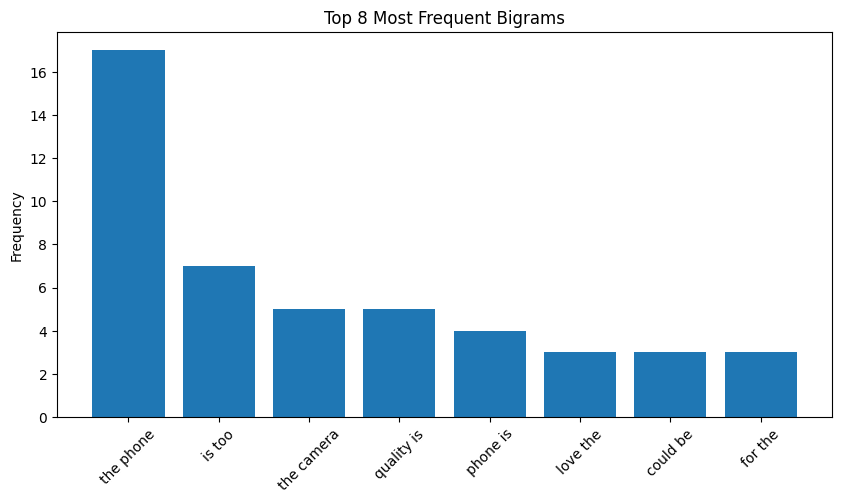

In [31]:
from nltk import ngrams

# Generate bigrams (2-word phrases)
all_words = ' '.join(df['review']).lower().split()
bigrams = list(ngrams(all_words, 2))
bigram_counts = Counter(bigrams).most_common(8)

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar([f"{bg[0][0]} {bg[0][1]}" for bg in bigram_counts], 
        [bg[1] for bg in bigram_counts])
plt.title("Top 8 Most Frequent Bigrams")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

## Task 4: TF-IDF Representation


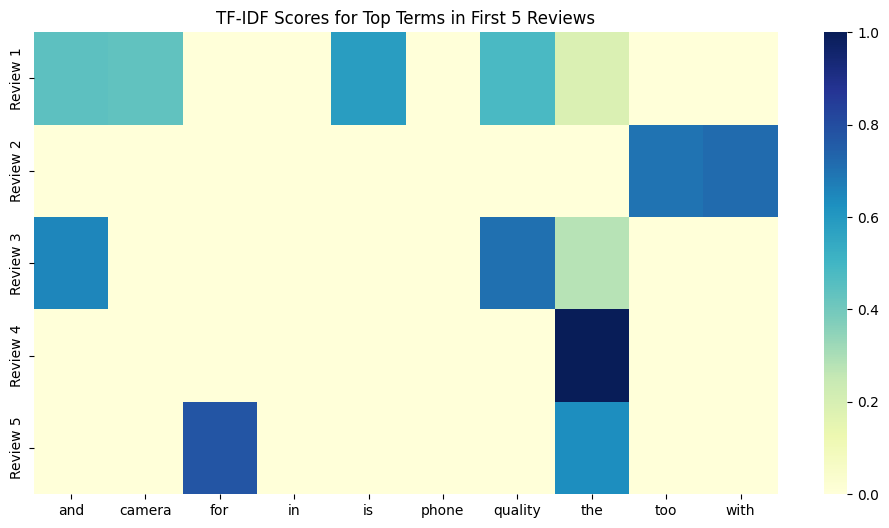

In [32]:
# Compute TF-IDF
vectorizer = TfidfVectorizer(max_features=10)
tfidf_matrix = vectorizer.fit_transform(df['review'])
feature_names = vectorizer.get_feature_names_out()

# Plot heatmap for first 5 reviews
plt.figure(figsize=(12, 6))
sns.heatmap(tfidf_matrix[:5].toarray(), 
            xticklabels=feature_names,
            yticklabels=[f"Review {i+1}" for i in range(5)],
            cmap="YlGnBu")
plt.title("TF-IDF Scores for Top Terms in First 5 Reviews")
plt.show()

Part B: Runtime Query Search


In [33]:
def search_reviews(query):
    # Add query as temporary document
    temp_docs = df['review'].tolist() + [query]
    
    # Compute TF-IDF
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(temp_docs)
    
    # Compare query to all documents
    cosine_similarities = cosine_similarity(tfidf_matrix[-1:], tfidf_matrix[:-1])
    
    # Find most similar
    most_similar_idx = np.argmax(cosine_similarities)
    
    print(f"Query: '{query}'")
    print(f"Most relevant review (similarity: {cosine_similarities[0][most_similar_idx]:.2f}):")
    print(df['review'].iloc[most_similar_idx])

# Example usage
search_reviews("battery life")

Query: 'battery life'
Most relevant review (similarity: 0.60):
Battery drains too quickly, not happy with battery life.


### Word Cloud


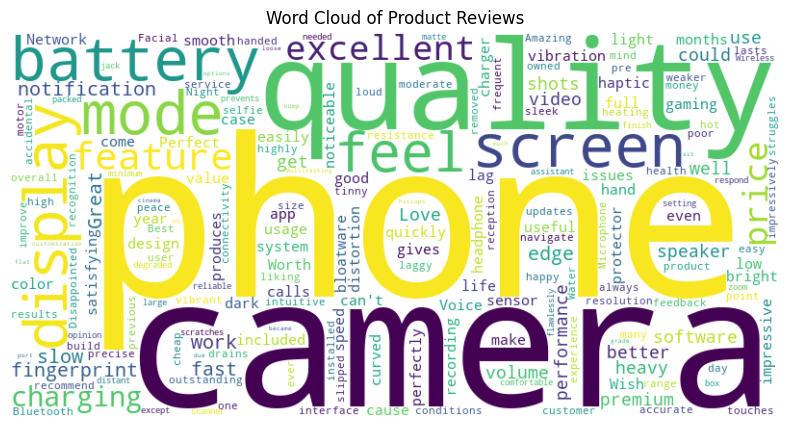

In [34]:
# Combine all reviews
all_text = ' '.join(df['review'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      stopwords=stop_words).generate(all_text)

# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Product Reviews")
plt.show()